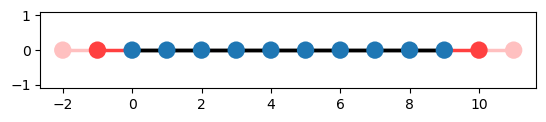

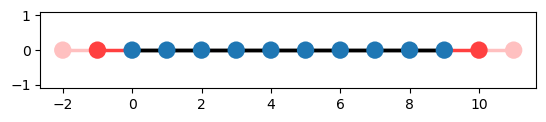

In [ ]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 1D 晶格（4 自由度 BdG）
# ======================
lat = kwant.lattice.chain(norbs=4)

# ======================
# 2. 参数
# ======================
dela = 1
t = 38 * dela
af = 2133.33 * dela
mu = 8 * dela
U = 1.9 * dela
mz = 7 * dela
h = 1.2 * np.sqrt(mu**2 + dela**2)

L = 10
theta = np.pi / 2
phi = np.pi / 4   # Josephson 相位

# ======================
# 3. 散射区 onsite
# ======================
onsite_4x4_scatter = np.array([
    [ U - mu + 2*t + mz,  0,  0,  0],
    [ 0,  U - mu + 2*t - mz,  0,  0],
    [ 0,  0, -U + mu - 2*t - mz,  0],
    [ 0,  0,  0, -U + mu - 2*t + mz]
], dtype=complex)

# ======================
# 4. 散射区 hopping
# ======================
hop_4x4_scatter = np.array([
    [ -t,  0,  0,  0],
    [  0, -t,  0,  0],
    [  0,  0,  t,  0],
    [  0,  0,  0,  t]
], dtype=complex)

# ======================
# 5. 构建散射区
# ======================
syst = kwant.Builder()

for i in range(L):
    syst[lat(i)] = onsite_4x4_scatter
    if i > 0:
        syst[lat(i-1), lat(i)] = hop_4x4_scatter

# ======================
# 6. Pauli 矩阵
# ======================
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

# ======================
# 7. 正常态 + 配对
# ======================
def He(mu, t, hx, hy, hz):
    return (2*t - mu) * s0 + hx*sx + hy*sy + hz*sz

def pairing(delta, phase=0):
    return delta * np.exp(1j*phase) * 1j * sy

def onsite_BdG(mu, t, delta, hx, hy, hz, phase=0):
    He_block = He(mu, t, hx, hy, hz)
    Delta = pairing(delta, phase)
    return np.block([
        [ He_block,        Delta        ],
        [ Delta.conj().T, -He_block.conj() ]
    ])

# ======================
# 8. Rashba SOC hopping
# ======================
def hop_4x4_soc(t, alpha):
    hop_e = -t*s0 + 1j*alpha*sy
    return np.block([
        [ hop_e,              np.zeros((2,2)) ],
        [ np.zeros((2,2)),   -hop_e.conj()    ]
    ])

# ======================
# 9. 左导线（φ 相位）
# ======================
lead_L = kwant.Builder(kwant.TranslationalSymmetry([-1]))

def onsite_left(site):
    return onsite_BdG(mu, t, dela, h, 0, 0, phase=phi)

lead_L[lat(0)] = onsite_left
lead_L[lat(0), lat(1)] = hop_4x4_soc(t, af)

# ======================
# 10. 右导线（旋转 Zeeman）
# ======================
lead_R = kwant.Builder(kwant.TranslationalSymmetry([1]))

def onsite_right(site):
    hx = h * np.cos(theta)
    hy = h * np.sin(theta)
    return onsite_BdG(mu, t, dela, hx, hy, 0, phase=0)

lead_R[lat(0)] = onsite_right
lead_R[lat(0), lat(1)] = hop_4x4_soc(t, af)

# ======================
# 11. 接导线
# ======================
syst.attach_lead(lead_L)
syst.attach_lead(lead_R)

# ======================
# 12. 手动指定接口 hopping（关键）
# ======================
syst[lat(L-1), lat(0)] = hop_4x4_scatter

# ======================
# 13. 画结构
# ======================
kwant.plot(syst)
